# Steam Oyun Katalogu - Kesifsel Veri Analizi (EDA)

Bu not defterinin amaci, eksik veri temizligi ve tek/cift degiskenli analiz tekniklerini bir oyun katalogu uzerinde uygulamaktir.

**Kullanilan veri seti (Kaggle):** `nikdavis/steam-store-games` - 27.000+ Steam oyunu; cikis tarihi, gelistirici, yayinci, platform destegi, tur (genres), basarim sayisi, oy sayisi, ortalama oynanma suresi ve fiyat kolonlarini icerir. Buyuk katalog boyutu ve kismen eksik kategorik kolonlar (developer/publisher gibi) icermesi nedeniyle bu veri seti secildi.

NOT: Bu not defteri 'Cift Degiskenli Analiz' basligindan sonra kasitli olarak tamamlanmamis (bos hucreler) birakilmistir.

In [1]:
# temel veri isleme kutuphaneleri
import pandas as pd
import numpy as np

# gorsellestirme kutuphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# istatistik kutuphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore')  # uyari mesajlarini kapatir
pd.set_option('display.max_columns', 50)  # buyuk veride kolon sayisini sinirlar
pd.set_option('display.max_rows', None)  # satiri sinirlamaz
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # virgulden sonra kac basamak

# grafik stili ayarlari
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('Tum kutuphaneler basariyla yuklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')
print(f'Seaborn version: {sns.__version__}')

Tum kutuphaneler basariyla yuklendi
Pandas version: 3.0.0
Numpy version: 2.3.2
Seaborn version: 0.13.2


## Veri Setini Yukleme

ÖĞRENME NOTU (yönlendirme): Veriyi Kaggle'dan `kagglehub` ile indirip okuyoruz. `nikdavis/steam-store-games` birden fazla CSV icerir (steam.csv, steam_description_data.csv, ...); bu analizde ana katalog dosyasi olan **steam.csv**'yi kullaniyoruz.

In [2]:
import os
import kagglehub

dataset_path = kagglehub.dataset_download('nikdavis/steam-store-games')
print('Veri seti yolu:', dataset_path)

csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith('.csv')]
print('Bulunan CSV dosyalari:', csv_files)

# Ana katalog dosyasi genelde 'steam.csv' adiyla gelir; bulunamazsa ilk CSV'ye dus
main_csv = 'steam.csv' if 'steam.csv' in csv_files else csv_files[0]
data_path = os.path.join(dataset_path, main_csv)
print('Kullanilacak dosya:', data_path)

df = pd.read_csv(data_path)

  0%|          | 0.00/35.2M [00:00<?, ?B/s]

  3%|▎         | 1.00M/35.2M [00:00<00:26, 1.36MB/s]

  6%|▌         | 2.00M/35.2M [00:01<00:19, 1.78MB/s]

  9%|▊         | 3.00M/35.2M [00:01<00:11, 2.82MB/s]

 11%|█▏        | 4.00M/35.2M [00:01<00:08, 3.76MB/s]

...

 97%|█████████▋| 34.0M/35.2M [00:06<00:00, 8.38MB/s]

 99%|█████████▉| 35.0M/35.2M [00:06<00:00, 8.16MB/s]

100%|██████████| 35.2M/35.2M [00:06<00:00, 5.70MB/s]

Extracting files...


Veri seti yolu: C:\Users\dragon\.cache\kagglehub\datasets\nikdavis\steam-store-games\versions\3
Bulunan CSV dosyalari: ['steam.csv', 'steamspy_tag_data.csv', 'steam_description_data.csv', 'steam_media_data.csv', 'steam_requirements_data.csv', 'steam_support_info.csv']
Kullanilacak dosya: C:\Users\dragon\.cache\kagglehub\datasets\nikdavis\steam-store-games\versions\3\steam.csv


In [3]:
# ilk 5 satir yazdirma
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [4]:
# rastgele bes satir
df.sample(5)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
8333,448790,Infinity Wings - Scout & Grunt,2016-03-11,1,XiNFiNiTY Games,OtakuMaker SARL,windows;mac;linux,0,Single-player;Steam Achievements;Full controll...,Action;Casual;Indie,Action;Indie;Casual,25,27,16,204,204,20000-50000,1.99
17559,719300,Daemonsgate,2017-10-25,1,Imagitec,Piko Interactive LLC;Classics Digital,windows;mac;linux,0,Single-player;Partial Controller Support,Action;Adventure;RPG,RPG;Action;Adventure,0,2,3,0,0,0-20000,5.19
24339,928690,覇県を握れ ～47都道府県大戦～,2018-11-22,0,Flying Panjandrum / ふらいんぐパンジャンドラム,Flying Panjandrum / ふらいんぐパンジャンドラム,windows,0,Single-player,Indie;Simulation;Strategy,Strategy;Indie;Simulation,0,4,0,0,0,0-20000,30.99
12981,582430,Jumping Tank,2017-01-20,1,Maximus.ez,Maximus.ez,windows,0,Single-player;Steam Trading Cards,Action;Adventure;Casual;Indie,Casual;Indie;Action,0,79,50,269,287,200000-500000,0.79
25955,994570,Outrunner 3,2019-02-04,1,Outcorp,Chess no choke games,windows,0,Single-player;Steam Achievements;Partial Contr...,Adventure;Indie,Indie;Adventure;Platformer,5,33,3,0,0,0-20000,0.79


In [5]:
# veri tiplerini bulalim
print('Veri tipleri')
print('=' * 40)
dtype_df = pd.DataFrame({
    'sutun': df.columns,
    'veri tipi': df.dtypes.values,
    'null degeri': df.isnull().sum().values,
    'null orani(%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'unique': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
           sutun veri tipi  null degeri  null orani(%)  unique
           appid     int64            0           0.00   27075
            name       str            0           0.00   27033
    release_date       str            0           0.00    2619
         english     int64            0           0.00       2
       developer       str            1           0.00   17112
       publisher       str           14           0.05   14353
       platforms       str            0           0.00       7
    required_age     int64            0           0.00       6
      categories       str            0           0.00    3333
          genres       str            0           0.00    1552
   steamspy_tags       str            0           0.00    6423
    achievements     int64            0           0.00     410
positive_ratings     int64            0           0.00    2800
negative_ratings     int64            0           0.00    1492
average_playtime     int64            0   

In [6]:
# sayisal degiskenlerle ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,27075.00,596203.51,250894.17,10.00,401230.00,599070.00,798760.00,1069460.00
english,27075.00,0.98,0.14,0.00,1.00,1.00,1.00,1.00
required_age,27075.00,0.35,2.41,0.00,0.00,0.00,0.00,18.00
achievements,27075.00,45.25,352.67,0.00,0.00,7.00,23.00,9821.00
positive_ratings,27075.00,1000.56,18988.72,0.00,6.00,24.00,126.00,2644404.00
negative_ratings,27075.00,211.03,4284.94,0.00,2.00,9.00,42.00,487076.00
average_playtime,27075.00,149.80,1827.04,0.00,0.00,0.00,0.00,190625.00
median_playtime,27075.00,146.06,2353.88,0.00,0.00,0.00,0.00,190625.00
price,27075.00,6.08,7.87,0.00,1.69,3.99,7.19,421.99


In [7]:
# kategorik degiskenlerin temel istatistikleri
df.describe(include=['object', 'category']).T

,count,unique,top,freq
name,27075,27033,Dark Matter,3
release_date,27075,2619,2018-07-13,64
developer,27074,17112,Choice of Games,94
publisher,27061,14353,Big Fish Games,212
platforms,27075,7,windows,18398
categories,27075,3333,Single-player,6110
genres,27075,1552,Action;Indie,1852
steamspy_tags,27075,6423,Action;Indie;Casual,845
owners,27075,13,0-20000,18596


In [8]:
# degisken turlerini ayir
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print('Sayisal kolonlar:', list(numeric_columns))
print('Kategorik kolonlar:', list(categorical_columns))

Sayisal kolonlar: ['appid', 'english', 'required_age', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'price']
Kategorik kolonlar: ['name', 'release_date', 'developer', 'publisher', 'platforms', 'categories', 'genres', 'steamspy_tags', 'owners']


### Eksik Veri Analizi

In [9]:
empty_values = df.isnull().sum()
empty_rate = (empty_values / len(df) * 100).round(2)
empty_df = pd.concat([empty_values, empty_rate], axis=1)
empty_df.columns = ['empty_count', 'empty_rate']
empty_df = empty_df.sort_values('empty_rate', ascending=False)

empty_df

,empty_count,empty_rate
publisher,14,0.05
appid,0,0.00
name,0,0.00
release_date,0,0.00
english,0,0.00
developer,1,0.00
platforms,0,0.00
required_age,0,0.00
categories,0,0.00
genres,0,0.00


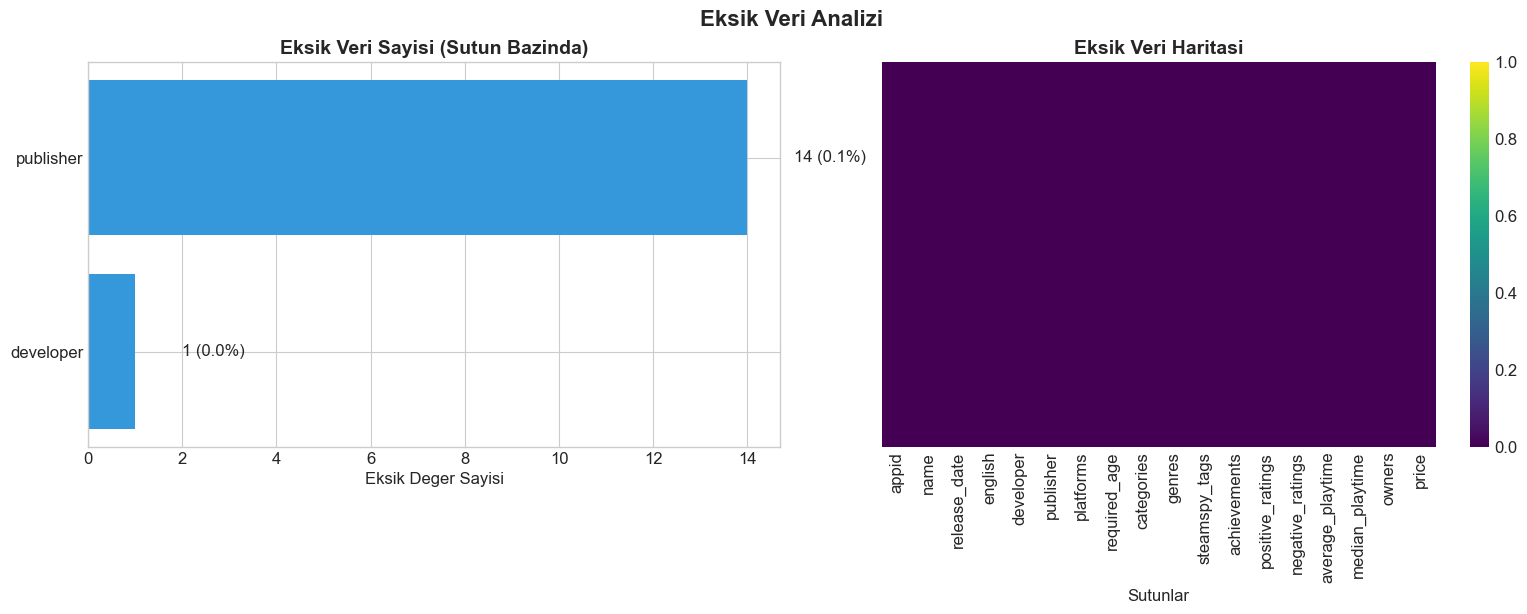

In [10]:
# eksik veri gorsellestirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

missing_only = df.isnull().sum()
missing_only = missing_only[missing_only > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (missing_only / len(df) * 100)]

if len(missing_only) > 0:
    axes[0].barh(missing_only.index, missing_only.values, color=colors)
    axes[0].set_title('Eksik Veri Sayisi (Sutun Bazinda)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Eksik Deger Sayisi')
    for i, (val, col) in enumerate(zip(missing_only.values, missing_only.index)):
        axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')
else:
    axes[0].text(0.5, 0.5, 'Eksik deger yok', ha='center', va='center')
    axes[0].set_title('Eksik Veri Sayisi (Sutun Bazinda)', fontsize=14, fontweight='bold')

sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('Eksik Veri Haritasi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sutunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [11]:
# aykiri deger fazla oldugunda sayisal verilerde medyan kullanilir.
# kategorik olan 'developer' icin sabit deger atiyoruz.
df_clean = df.copy()

df_clean['developer'] = df_clean['developer'].fillna('Belirsiz')
print(df_clean.isnull().sum())

appid                0
name                 0
release_date         0
english              0
developer            0
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64


In [12]:
# mod, en cok gorulen degerle doldurur
# Steam veri setindeki 'publisher' sutununu kullaniyoruz
publisher_mode = df_clean['publisher'].mode()[0]
df_clean['publisher'] = df_clean['publisher'].fillna(publisher_mode)
print(df_clean.isnull().sum())

appid               0
name                0
release_date        0
english             0
developer           0
publisher           0
platforms           0
required_age        0
categories          0
genres              0
steamspy_tags       0
achievements        0
positive_ratings    0
negative_ratings    0
average_playtime    0
median_playtime     0
owners              0
price               0
dtype: int64


### Tek Degiskenli Analiz

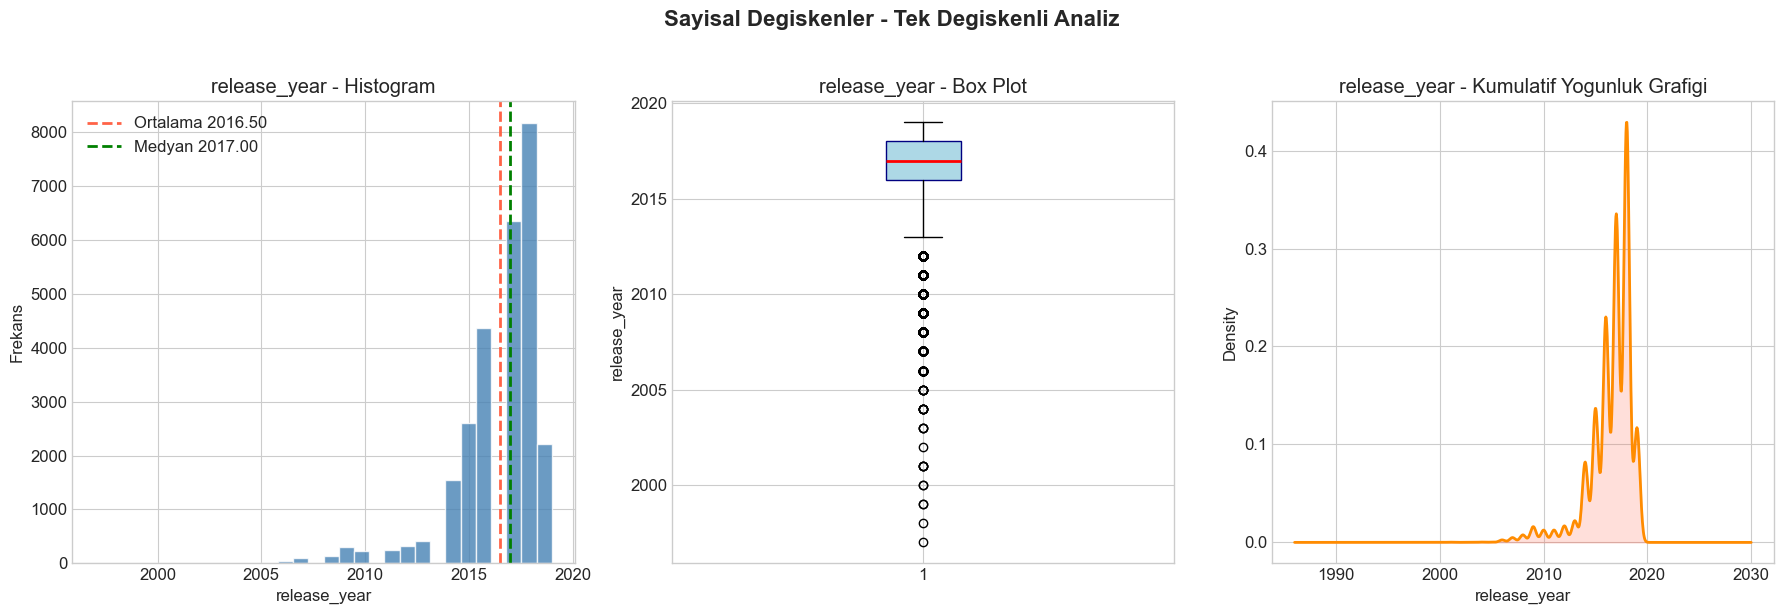

In [13]:
# release_date kolonundan sayisal bir 'release_year' kolonu turetiyoruz
# (Steam veri setinde metin olarak geldigi icin burada parse ediyoruz).
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year

numeric_cols_to_plot = ['release_year']

fig, axes = plt.subplots(len(numeric_cols_to_plot), 3, figsize=(18, 6 * len(numeric_cols_to_plot)))
if len(numeric_cols_to_plot) == 1:
    axes = np.array([axes])

for i, col in enumerate(numeric_cols_to_plot):
    data = df_clean[col].dropna()

    axes[i, 0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(data.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama {data.mean():.2f}')
    axes[i, 0].axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan {data.median():.2f}')
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekans')

    axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{col} - Box Plot')
    axes[i, 1].set_ylabel(col)

    data.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].fill_between(axes[i, 2].lines[0].get_xdata(),
                             axes[i, 2].lines[0].get_ydata(),
                             color='tomato', alpha=0.2)
    axes[i, 2].set_title(f'{col} - Kumulatif Yogunluk Grafigi')
    axes[i, 2].set_xlabel(col)

plt.suptitle('Sayisal Degiskenler - Tek Degiskenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# istatistiksel ozet tablo
print('Sayisal Degiskenler Detayli Istatistikler:')
print('=' * 70)

for col in numeric_cols_to_plot:
    data = df_clean[col].dropna()
    print(f'\n* {col.upper()}')
    print(f'Ortalama: {data.mean():.2f}')
    print(f'Medyan: {data.median():.2f}')
    print(f'Standart Sapma: {data.std():.2f}')
    print(f'Minimum: {data.min():.2f}')
    print(f'Maksimum: {data.max():.2f}')
    print(f'Varyans: {data.var():.2f}')
    print(f'Skewness (Carpiklik): {data.skew():.2f}')
    print(f'Kurtosis (Basiklik): {data.kurtosis():.2f}')
    print(f'IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}')
    print('=' * 70)

Sayisal Degiskenler Detayli Istatistikler:

* RELEASE_YEAR
Ortalama: 2016.50
Medyan: 2017.00
Standart Sapma: 2.16
Minimum: 1997.00
Maksimum: 2019.00
Varyans: 4.65
Skewness (Carpiklik): -2.04
Kurtosis (Basiklik): 6.08
IQR: 2.00


### Kategorik Kolon

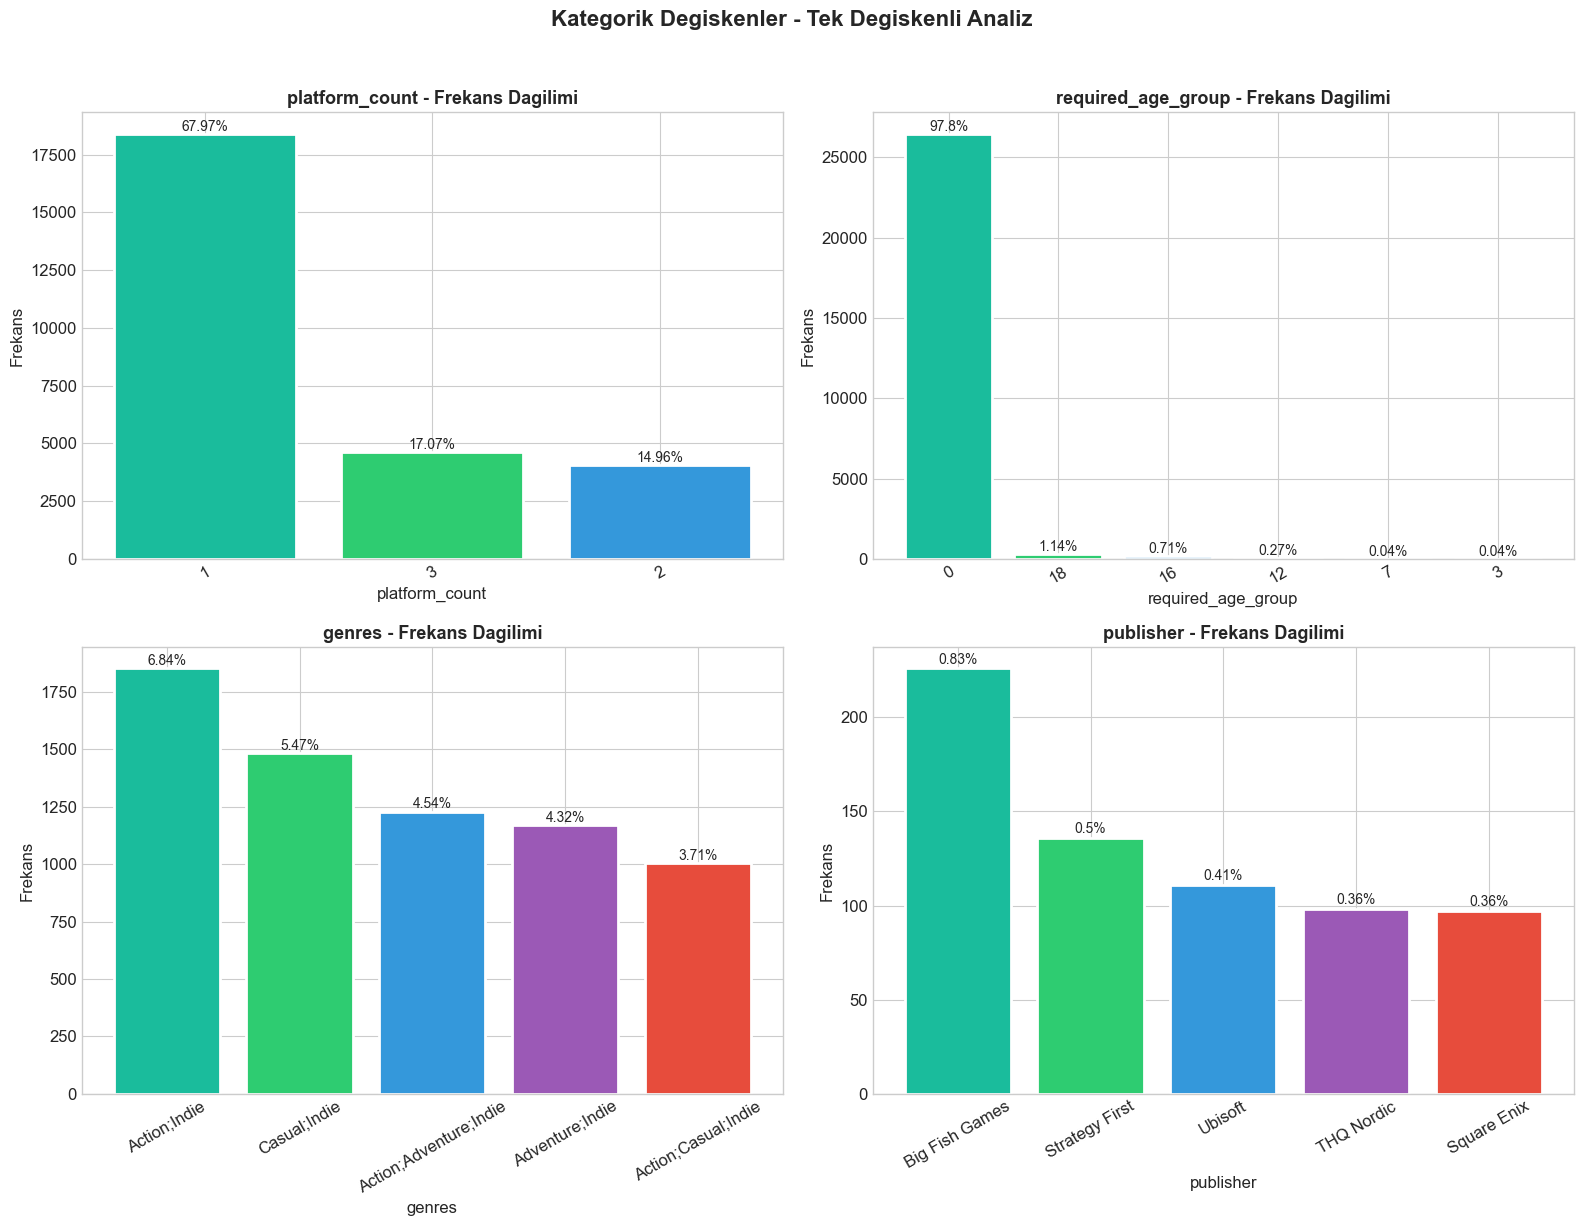

In [15]:
# platform destegini az sayida kategoriye sahip bir alana indirgeyelim: platformlar noktali virgulle
# ayrilmis geliyor (ornek: 'windows;mac;linux') - kac platform destekledigini sayalim.
df_clean['platform_count'] = df_clean['platforms'].astype(str).str.split(';').apply(len)
df_clean['required_age_group'] = df_clean['required_age'].astype(str)

categorical_cols_to_plot = ['platform_count', 'required_age_group', 'genres', 'publisher']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#1ABC9C', '#2ECC71', '#3498DB', '#9B59B6', '#E74C3C', '#F1C40F']
for i, col in enumerate(categorical_cols_to_plot):
    # cok fazla benzersiz degere sahip genres/publisher icin en populer ilk 5 degeri aliyoruz
    if col in ['genres', 'publisher']:
        counts = df_clean[col].value_counts().head(5)
    else:
        counts = df_clean[col].value_counts()

    pct = (counts / len(df_clean) * 100).round(2)

    bars = axes[i].bar(counts.index.astype(str), counts.values,
                        color=colors[:len(counts)], edgecolor='white', linewidth=2)

    axes[i].set_title(f'{col} - Frekans Dagilimi', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=30)

    for bar, p in zip(bars, pct.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 1,
                      f'{p}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Kategorik Degiskenler - Tek Degiskenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Cift Degiskenli Analiz